<a href="https://colab.research.google.com/github/SouravDasz/Emotion-detector/blob/main/emotion_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! mkdir -p /.kaggle

In [ ]:
! cp kaggle.json ~/.kaggle

cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
! kaggle datasets download -d fahadullaha/facial-emotion-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/fahadullaha/facial-emotion-recognition-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 200M/200M [00:01<00:00, 140MB/s]



In [ ]:
pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.8 MB/s eta 0:00:00


In [ ]:
from mtcnn import MTCNN

In [ ]:
import cv2

In [ ]:
import zipfile

zip=zipfile.ZipFile("/content/facial-emotion-recognition-dataset.zip")
zip.extractall("/content")
zip.close()

In [ ]:
pip uninstall -y pillow

Found existing installation: pillow 11.3.0
Uninstalling pillow-11.3.0:
  Successfully uninstalled pillow-11.3.0


In [ ]:
pip install pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 79.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


In [ ]:
from PIL import Image,ImageDraw,ImageFont

In [ ]:
import torch.nn as nn
from torchvision import datasets,transforms
import  torch.optim as optim
from torch.utils.data import DataLoader,Dataset
import torch

In [ ]:
# laod dataset
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_ds=datasets.ImageFolder(
    "/content/processed_data",
    transform=transform
)

In [ ]:
# dataloader

dataloader=DataLoader(
    train_ds,batch_size=32,shuffle=True
)

In [ ]:
dataloader.batch_size


32

In [ ]:
dict=train_ds.class_to_idx

In [ ]:
for images, labels in dataloader:
    print(images.shape)  # (32, 1, 48, 48)
    print(labels)
    break

torch.Size([32, 3, 224, 224])
tensor([1, 4, 6, 3, 6, 6, 4, 0, 3, 4, 1, 3, 5, 0, 1, 0, 5, 3, 5, 2, 0, 0, 4, 3,
        4, 0, 2, 1, 3, 1, 4, 6])


In [ ]:
# model building

class Emotion_detection(nn.Module):
  def __init__(self):
    super().__init__()

    self.feature=nn.Sequential(
        nn.Conv2d(in_channels=3,out_channels=64,kernel_size=3,padding="same"),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2,stride=2),
        nn.Conv2d(64,128,kernel_size=3,padding="same"),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(128,128,kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),
        nn.Conv2d(128,128,kernel_size=3),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),
    )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(128*12*12,128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128,7)

    )
  def forward(self,x):
    x=self.feature(x)
    x=self.classifier(x)
    return x

In [ ]:
model=Emotion_detection()

In [ ]:
model

Emotion_detection(
  (feature): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=184

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda')

In [ ]:
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(15):
    epoch_loss = 0
    total = 0
    correct = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 🔥 accumulate loss
        epoch_loss += loss.item()

        # 🔥 accuracy calculation
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {acc:.2f}%")

Epoch 1, Loss: 2268.3372, Accuracy: 43.01%
Epoch 2, Loss: 1894.9902, Accuracy: 53.51%
Epoch 3, Loss: 1710.6053, Accuracy: 58.01%
Epoch 4, Loss: 1567.6492, Accuracy: 61.61%
Epoch 5, Loss: 1415.3375, Accuracy: 65.40%
Epoch 6, Loss: 1250.8653, Accuracy: 69.66%
Epoch 7, Loss: 1079.9025, Accuracy: 73.92%
Epoch 8, Loss: 936.4692, Accuracy: 77.42%
Epoch 9, Loss: 807.3991, Accuracy: 80.60%
Epoch 10, Loss: 709.6476, Accuracy: 82.91%
Epoch 11, Loss: 624.7029, Accuracy: 84.94%
Epoch 12, Loss: 559.7163, Accuracy: 86.58%
Epoch 13, Loss: 516.4929, Accuracy: 87.69%
Epoch 14, Loss: 472.9421, Accuracy: 88.72%
Epoch 15, Loss: 418.1014, Accuracy: 90.25%


In [ ]:
img="/content/processed_data/happy/happy_01416.jpg"

In [ ]:
img=cv2.imread(img)

array([[[ 69,  69,  69],
        [ 70,  70,  70],
        [ 73,  73,  73],
        ...,
        [ 46,  46,  46],
        [ 46,  46,  46],
        [ 46,  46,  46]],

       [[ 73,  73,  73],
        [ 74,  74,  74],
        [ 78,  78,  78],
        ...,
        [ 46,  46,  46],
        [ 46,  46,  46],
        [ 46,  46,  46]],

       [[ 81,  81,  81],
        [ 82,  82,  82],
        [ 86,  86,  86],
        ...,
        [ 46,  46,  46],
        [ 46,  46,  46],
        [ 46,  46,  46]],

       ...,

       [[197, 197, 197],
        [196, 196, 196],
        [194, 194, 194],
        ...,
        [102, 102, 102],
        [102, 102, 102],
        [102, 102, 102]],

       [[196, 196, 196],
        [195, 195, 195],
        [193, 193, 193],
        ...,
        [101, 101, 101],
        [101, 101, 101],
        [100, 100, 100]],

       [[196, 196, 196],
        [195, 195, 195],
        [193, 193, 193],
        ...,
        [101, 101, 101],
        [100, 100, 100],
        [ 99,  99,  99]]], dtype=uint8)
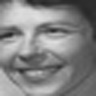

In [ ]:
img

In [ ]:
img=cv2.resize(img,(224,224))

array([[[ 69,  69,  69],
        [ 69,  69,  69],
        [ 69,  69,  69],
        ...,
        [ 46,  46,  46],
        [ 46,  46,  46],
        [ 46,  46,  46]],

       [[ 69,  69,  69],
        [ 69,  69,  69],
        [ 70,  70,  70],
        ...,
        [ 46,  46,  46],
        [ 46,  46,  46],
        [ 46,  46,  46]],

       [[ 71,  71,  71],
        [ 71,  71,  71],
        [ 72,  72,  72],
        ...,
        [ 46,  46,  46],
        [ 46,  46,  46],
        [ 46,  46,  46]],

       ...,

       [[196, 196, 196],
        [196, 196, 196],
        [195, 195, 195],
        ...,
        [100, 100, 100],
        [100, 100, 100],
        [ 99,  99,  99]],

       [[196, 196, 196],
        [196, 196, 196],
        [195, 195, 195],
        ...,
        [100, 100, 100],
        [ 99,  99,  99],
        [ 99,  99,  99]],

       [[196, 196, 196],
        [196, 196, 196],
        [195, 195, 195],
        ...,
        [ 99,  99,  99],
        [ 99,  99,  99],
        [ 99,  99,  99]]], dtype=uint8)
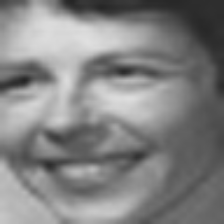

In [ ]:
img

In [ ]:
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

array([[[ 69,  69,  69],
        [ 69,  69,  69],
        [ 69,  69,  69],
        ...,
        [ 46,  46,  46],
        [ 46,  46,  46],
        [ 46,  46,  46]],

       [[ 69,  69,  69],
        [ 69,  69,  69],
        [ 70,  70,  70],
        ...,
        [ 46,  46,  46],
        [ 46,  46,  46],
        [ 46,  46,  46]],

       [[ 71,  71,  71],
        [ 71,  71,  71],
        [ 72,  72,  72],
        ...,
        [ 46,  46,  46],
        [ 46,  46,  46],
        [ 46,  46,  46]],

       ...,

       [[196, 196, 196],
        [196, 196, 196],
        [195, 195, 195],
        ...,
        [100, 100, 100],
        [100, 100, 100],
        [ 99,  99,  99]],

       [[196, 196, 196],
        [196, 196, 196],
        [195, 195, 195],
        ...,
        [100, 100, 100],
        [ 99,  99,  99],
        [ 99,  99,  99]],

       [[196, 196, 196],
        [196, 196, 196],
        [195, 195, 195],
        ...,
        [ 99,  99,  99],
        [ 99,  99,  99],
        [ 99,  99,  99]]], dtype=uint8)
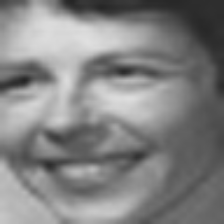

In [ ]:
img

In [ ]:
img=torch.from_numpy(img)

In [ ]:
img

tensor([[[ 69,  69,  69],
         [ 69,  69,  69],
         [ 69,  69,  69],
         ...,
         [ 46,  46,  46],
         [ 46,  46,  46],
         [ 46,  46,  46]],

        [[ 69,  69,  69],
         [ 69,  69,  69],
         [ 70,  70,  70],
         ...,
         [ 46,  46,  46],
         [ 46,  46,  46],
         [ 46,  46,  46]],

        [[ 71,  71,  71],
         [ 71,  71,  71],
         [ 72,  72,  72],
         ...,
         [ 46,  46,  46],
         [ 46,  46,  46],
         [ 46,  46,  46]],

        ...,

        [[196, 196, 196],
         [196, 196, 196],
         [195, 195, 195],
         ...,
         [100, 100, 100],
         [100, 100, 100],
         [ 99,  99,  99]],

        [[196, 196, 196],
         [196, 196, 196],
         [195, 195, 195],
         ...,
         [100, 100, 100],
         [ 99,  99,  99],
         [ 99,  99,  99]],

        [[196, 196, 196],
         [196, 196, 196],
         [195, 195, 195],
         ...,
         [ 99,  99,  99],
        

In [ ]:
print(type(img))

<class 'torch.Tensor'>


In [ ]:
img = img.permute(2, 0, 1)

In [ ]:
img=img.reshape(1,3,224,224)

In [ ]:
img

tensor([[[[ 69,  69,  69,  ...,  46,  46,  46],
          [ 69,  69,  70,  ...,  46,  46,  46],
          [ 71,  71,  72,  ...,  46,  46,  46],
          ...,
          [196, 196, 195,  ..., 100, 100,  99],
          [196, 196, 195,  ..., 100,  99,  99],
          [196, 196, 195,  ...,  99,  99,  99]],

         [[ 69,  69,  69,  ...,  46,  46,  46],
          [ 69,  69,  70,  ...,  46,  46,  46],
          [ 71,  71,  72,  ...,  46,  46,  46],
          ...,
          [196, 196, 195,  ..., 100, 100,  99],
          [196, 196, 195,  ..., 100,  99,  99],
          [196, 196, 195,  ...,  99,  99,  99]],

         [[ 69,  69,  69,  ...,  46,  46,  46],
          [ 69,  69,  70,  ...,  46,  46,  46],
          [ 71,  71,  72,  ...,  46,  46,  46],
          ...,
          [196, 196, 195,  ..., 100, 100,  99],
          [196, 196, 195,  ..., 100,  99,  99],
          [196, 196, 195,  ...,  99,  99,  99]]]], dtype=torch.uint8)

In [ ]:
img=img.to(device)

In [ ]:
img = img.float() / 255.0

In [ ]:
model(img)

tensor([[  1.8982, -33.6531, -11.3694,  21.0150,   0.7122,  -8.2877, -10.1018]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
import torch

x = torch.tensor([1.8982, -33.6531, -11.3694, 21.0150, 0.7122, -8.2877, -10.1018])

print(torch.argmax(x))

tensor(3)


In [ ]:
dict.items()

dict_items([('angry', 0), ('disgust', 1), ('fear', 2), ('happy', 3), ('neutral', 4), ('sad', 5), ('surprise', 6)])

In [ ]:
dict={v : k for k,v in dict.items()}

In [ ]:
dict

{0: 'angry',
 1: 'disgust',
 2: 'fear',
 3: 'happy',
 4: 'neutral',
 5: 'sad',
 6: 'surprise'}

In [ ]:
dict[3]

'happy'

In [ ]:
model.eval()
with torch.no_grad():              # disables gradient computation
    output = model(img)     # shape: (1, num_classes)
    pred = torch.argmax(output, dim=1).item()  # get class index

In [ ]:
pred

3

In [ ]:
torch.save(model,"emotion.pth")

In [ ]:
pip install torchinfo

In [ ]:
from torchinfo import summary

In [ ]:
summary(model)

Layer (type:depth-idx)                   Param #
Emotion_detection                        --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       1,792
│    └─ReLU: 2-2                         --
│    └─BatchNorm2d: 2-3                  128
│    └─MaxPool2d: 2-4                    --
│    └─Conv2d: 2-5                       73,856
│    └─ReLU: 2-6                         --
│    └─BatchNorm2d: 2-7                  256
│    └─MaxPool2d: 2-8                    --
│    └─Conv2d: 2-9                       147,584
│    └─ReLU: 2-10                        --
│    └─MaxPool2d: 2-11                   --
│    └─Conv2d: 2-12                      147,584
│    └─ReLU: 2-13                        --
│    └─MaxPool2d: 2-14                   --
├─Sequential: 1-2                        --
│    └─Flatten: 2-15                     --
│    └─Linear: 2-16                      2,359,424
│    └─ReLU: 2-17                        --
│    └─Dropout: 2-18                     --
│

In [ ]:
for name, param in model.named_parameters():
    print(name, param.shape)

feature.0.weight torch.Size([64, 3, 3, 3])
feature.0.bias torch.Size([64])
feature.2.weight torch.Size([64])
feature.2.bias torch.Size([64])
feature.4.weight torch.Size([128, 64, 3, 3])
feature.4.bias torch.Size([128])
feature.6.weight torch.Size([128])
feature.6.bias torch.Size([128])
feature.8.weight torch.Size([128, 128, 3, 3])
feature.8.bias torch.Size([128])
feature.11.weight torch.Size([128, 128, 3, 3])
feature.11.bias torch.Size([128])
classifier.1.weight torch.Size([128, 18432])
classifier.1.bias torch.Size([128])
classifier.4.weight torch.Size([7, 128])
classifier.4.bias torch.Size([7])
